In [242]:
import pandas as pd
import numpy as np
import seaborn as sns

In [243]:
df = pd.read_csv('../data/train.csv')

df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [244]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

the dytpes of the data is in the format that is needed but there are alot of null values.

but before that we will be checking for the duplicates

In [245]:
df.duplicated().sum()

np.int64(0)

In [246]:
df[df.duplicated()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


no duplicate values.

In [247]:
df.isnull().sum().sum()

np.int64(7829)

we got total 7829 null values. we need to clean them but verycarefully without removing the important values 

In [248]:
df.isnull().sum().sort_values(ascending=False)

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64

we will be start from the top 20 values.

In [249]:
df.isnull().sum().sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64

we will be removing the below values as they have alot of null values.. that also means any house that has the null value of in these below options means they do not have these features.
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179

In [250]:
drop_cols = [
    'PoolQC' ,       
    'MiscFeature'  ,   
    'Alley'    ,       
    'Fence'  ,         
]

In [251]:
df = df.drop(drop_cols, axis=1)

In [252]:
df.isnull().sum().sort_values(ascending=False).head(20)

MasVnrType      872
FireplaceQu     690
LotFrontage     259
GarageFinish     81
GarageQual       81
GarageCond       81
GarageType       81
GarageYrBlt      81
BsmtExposure     38
BsmtFinType2     38
BsmtCond         37
BsmtFinType1     37
BsmtQual         37
MasVnrArea        8
Electrical        1
LandSlope         0
LotConfig         0
Condition1        0
Neighborhood      0
LotShape          0
dtype: int64

the nest coming is MasVnrType- for these features we can mention that there is No_MasVnr

In [253]:
df['MasVnrType'] = df['MasVnrType'].fillna('No_MasVnr')

In [254]:
df.isnull().sum().sort_values(ascending=False).head(20)

FireplaceQu     690
LotFrontage     259
GarageFinish     81
GarageYrBlt      81
GarageQual       81
GarageCond       81
GarageType       81
BsmtExposure     38
BsmtFinType2     38
BsmtCond         37
BsmtQual         37
BsmtFinType1     37
MasVnrArea        8
Electrical        1
Neighborhood      0
LandSlope         0
LotConfig         0
Condition1        0
LandContour       0
LotShape          0
dtype: int64

we are going to do the same for the FireplaceQu - No_firePlace

In [255]:
df['FireplaceQu'] = df['FireplaceQu'].fillna("No_FirePlace")

In [256]:
df.isnull().sum().sort_values(ascending=False).head(5)

LotFrontage    259
GarageCond      81
GarageType      81
GarageYrBlt     81
GarageQual      81
dtype: int64

for LotFrontage    we are going to use a different approach.. we are going to use the median to fill the null values for LotFrontage    

In [257]:
df['LotFrontage']

0       65.0
1       80.0
2       68.0
3       60.0
4       84.0
        ... 
1455    62.0
1456    85.0
1457    66.0
1458    68.0
1459    75.0
Name: LotFrontage, Length: 1460, dtype: float64

In [258]:
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

In [259]:
df.isnull().sum().sort_values(ascending=False).head(6)

GarageFinish    81
GarageCond      81
GarageType      81
GarageYrBlt     81
GarageQual      81
BsmtFinType2    38
dtype: int64

Now we are going to use a different approch whent it comes for garage for finish, condition, type and quality  null values we are going to use No_garage but for Garage yrblt we are going to use median for numeric features.. we are going to fill it with most common values available.

In [260]:
garage_col = [
    'GarageFinish',
    'GarageCond',
    'GarageType',
    'GarageQual'
]

In [261]:
for col in garage_col:
    df[col] = df[col].fillna("No_Garage")

In [262]:
df.isnull().sum().sort_values(ascending=False).head(6)

GarageYrBlt     81
BsmtFinType2    38
BsmtExposure    38
BsmtQual        37
BsmtFinType1    37
BsmtCond        37
dtype: int64

In [263]:
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['GarageYrBlt'].median())

In [264]:
df.isnull().sum().sort_values(ascending=False).head(6)

BsmtFinType2    38
BsmtExposure    38
BsmtQual        37
BsmtCond        37
BsmtFinType1    37
MasVnrArea       8
dtype: int64

In similar way we are going to fill the null values for basement as no basement.

In [265]:
bsmt_cols = [
    'BsmtFinType2',
    'BsmtExposure',
    'BsmtQual',
    'BsmtCond',
    'BsmtFinType1'
]

In [266]:
for col in bsmt_cols:
    df[col] = df[col].fillna('No_Bsmt')

In [267]:
df.isnull().sum().sort_values(ascending=False).head(6)

MasVnrArea    8
Electrical    1
MSZoning      0
MSSubClass    0
Id            0
Street        0
dtype: int64

In [268]:
df['MasVnrArea']

0       196.0
1         0.0
2       162.0
3         0.0
4       350.0
        ...  
1455      0.0
1456    119.0
1457      0.0
1458      0.0
1459      0.0
Name: MasVnrArea, Length: 1460, dtype: float64

for the values of MasVnrArea  we are going to use median to fill the data is it only showing for the house that has masvnr but we dont no the exact area of the house.

In [269]:
df['MasVnrArea'] = df['MasVnrArea'].fillna(df['MasVnrArea'].median())

In [270]:
df.isnull().sum().sort_values(ascending=False).head(6)

Electrical     1
MSSubClass     0
MSZoning       0
LotFrontage    0
Id             0
Street         0
dtype: int64

No we are only left with Electricals. we are going to use mode for fill the missing values of electricals as it is categorical feature.

In [271]:
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [272]:
df.isnull().sum().sort_values(ascending=False).head()

Id             0
MSSubClass     0
MSZoning       0
LotFrontage    0
LotArea        0
dtype: int64

We have clear the data with no more null values and duplicate values.

In [273]:
print('The Dataset is cleaned')
print('Null Values: ', df.isnull().sum().sum())
print('Duplicate Values: ', df.duplicated().sum())

The Dataset is cleaned
Null Values:  0
Duplicate Values:  0


In [274]:
df.to_csv('../Day11_revision/Cleaned_House_price_dataSet.csv')

Now as our dataset is cleaned now we will be splitting the features and target for training


In [275]:
df.head(1)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,208500


as we can see the SalePrice is our target lets check the how the values are distributed

<Axes: xlabel='SalePrice', ylabel='Count'>

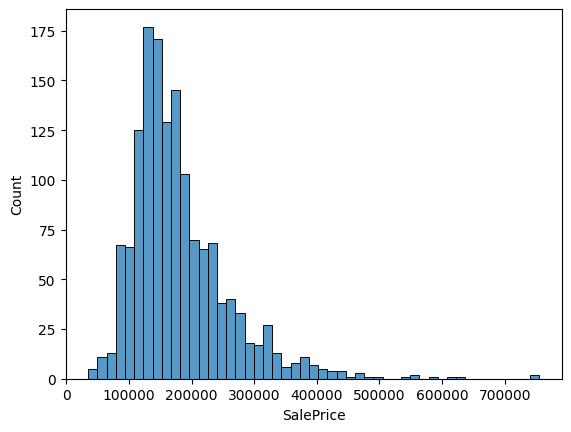

In [276]:
sns.histplot(df['SalePrice'])

these values are highly left skewed and because the amounts are very high it will be so it can create problems for the prediction for machine while learning the data.

<Axes: xlabel='log_Sales_price', ylabel='Count'>

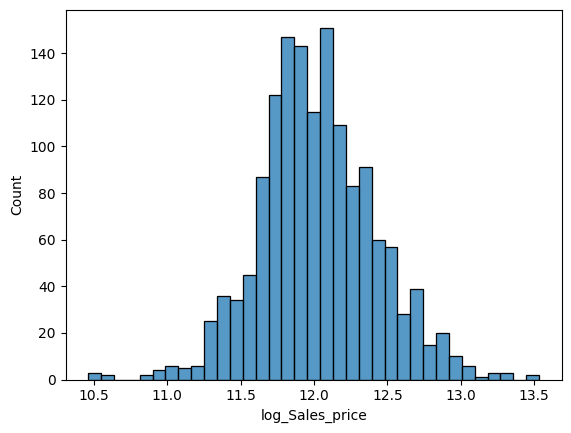

In [277]:
df['log_Sales_price'] = np.log1p(df['SalePrice'])

sns.histplot(df['log_Sales_price'])

bescause of this tranformation feature of salesprice no we have log_sale_price which is small and balanced.
now we can separate the our features X and target y.. and becarful while doing that to avoid any data leak

In [278]:
X = df.drop(df[['SalePrice','log_Sales_price']], axis=1)

print("Shape of X: ", X.shape)
X.columns

Shape of X:  (1460, 76)


Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'WoodD

In [279]:
y = df['log_Sales_price']

print('Shape of y: ', y.shape)

Shape of y:  (1460,)


Now we will split the training data and testing data.

In [280]:
from sklearn.model_selection import train_test_split

In [281]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=.20, random_state=42
)

print('Shape of X_train', X_train.shape)
print('Shape of y_train', y_train.shape)
print('Shape of X_test', X_test.shape)
print('Shape of y_test', y_test.shape)

Shape of X_train (1168, 76)
Shape of y_train (1168,)
Shape of X_test (292, 76)
Shape of y_test (292,)


now lets make the numeric and categorical -features, preprocessor and pipelines.

In [282]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 76 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

In [283]:
numeric_features = X.select_dtypes(
    include=['int64','float64']
).columns

categorical_features = X.select_dtypes(
    include=['str']
).columns

print(len(numeric_features))
print(len(categorical_features))

37
39


In [284]:
print(37+39)

76


Now we will be making the numeric and categorical pipeline.

In [285]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [286]:
numeric_pp = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pp = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

now we will make the preprocessor

In [287]:
prepro = ColumnTransformer([
    ('num', numeric_pp, numeric_features),
    ('cat', categorical_pp,categorical_features)
])

numeric and categorical features and pipeline are ready. preprocessor is ready. now we have to make the pipeline for the models.

starting from linear regression, lasso, ridge, descision tress, random forest, greadientboosting, XGboost.

In [288]:
from sklearn.linear_model import LinearRegression

In [289]:
lin_reg_pp = Pipeline([
    ('preprocessor', prepro),
    ('model', LinearRegression())
])

In [290]:
lin_reg_pp.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [291]:
pred_lin_Reg = lin_reg_pp.predict(X_test)

Now will be checing the scores of the predictions

In [292]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,root_mean_squared_error,r2_score

In [293]:
print('Scores for Linear regression\n')
print('R2 Score: ', r2_score(y_test, pred_lin_Reg))
print('MAE:  ',mean_absolute_error(y_test, pred_lin_Reg))
print('MSE: ', mean_squared_error(y_test, pred_lin_Reg))
print('RMSE: ',root_mean_squared_error(y_test,pred_lin_Reg))

Scores for Linear regression

R2 Score:  0.910281679409496
MAE:   0.08985856156360858
MSE:  0.01674242449994158
RMSE:  0.12939252103557447


now we will be doing for lasso

In [294]:
from sklearn.linear_model import Lasso

In [296]:
lasso_pp = Pipeline([
    ('preprocessor', prepro),
    ('model', Lasso(alpha=0.1))
])

In [297]:
lasso_pp.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [298]:
pred_lasso = lasso_pp.predict(X_test)

In [299]:
print('Scores for Lasso regression\n')
print('R2 Score: ', r2_score(y_test, pred_lasso))
print('MAE:  ',mean_absolute_error(y_test, pred_lasso))
print('MSE: ', mean_squared_error(y_test, pred_lasso))
print('RMSE: ',root_mean_squared_error(y_test,pred_lasso))

Scores for Lasso regression

R2 Score:  0.6894689057524699
MAE:   0.171090784768358
MSE:  0.05794851448516522
RMSE:  0.24072497686190608


now lets do ridge regression

In [302]:
from sklearn.linear_model import Ridge

In [304]:
Ridge_pp = Pipeline([
    ('preprocessor', prepro),
    ('model', Ridge(alpha=1.0))
])

In [309]:
Ridge_pp.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [310]:
pred_ridge = Ridge_pp.predict(X_test)

print('Scores for Ridge regression\n')
print('R2 Score: ', r2_score(y_test, pred_ridge))
print('MAE:  ',mean_absolute_error(y_test, pred_ridge))
print('MSE: ', mean_squared_error(y_test, pred_ridge))
print('RMSE: ',root_mean_squared_error(y_test,pred_ridge))

Scores for Ridge regression

R2 Score:  0.912425803936728
MAE:   0.09135643838843616
MSE:  0.016342307302256838
RMSE:  0.12783703415777775


Now we will do decision tree


In [323]:
from sklearn.tree import DecisionTreeRegressor

In [324]:
DTC_pp = Pipeline([
    ("preprocessor",prepro),
    ('model',DecisionTreeRegressor(random_state=42))
])

In [325]:
DTC_pp.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [326]:
pred_DTC = DTC_pp.predict(X_test)

print('Scores for Decision Tree regression\n')
print('R2 Score: ', r2_score(y_test, pred_DTC))
print('MAE:  ',mean_absolute_error(y_test, pred_DTC))
print('MSE: ', mean_squared_error(y_test, pred_DTC))
print('RMSE: ',root_mean_squared_error(y_test,pred_DTC))

Scores for Decision Tree regression

R2 Score:  0.7744974445928172
MAE:   0.1449477639862502
MSE:  0.042081254793887156
RMSE:  0.2051371609286995


now lets do Random forest regressor

In [327]:
from sklearn.ensemble import RandomForestRegressor

In [328]:
RFR_pp = Pipeline([
    ('preprocessor', prepro),
    ('model', RandomForestRegressor(random_state=42))
])

In [329]:
RFR_pp.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [330]:
pred_RFR = RFR_pp.predict(X_test)

print('Scores for Random forest regression\n')
print('R2 Score: ', r2_score(y_test, pred_RFR))
print('MAE:  ',mean_absolute_error(y_test, pred_RFR))
print('MSE: ', mean_squared_error(y_test, pred_RFR))
print('RMSE: ',root_mean_squared_error(y_test,pred_RFR))

Scores for Random forest regression

R2 Score:  0.8852999970616506
MAE:   0.09965891212663866
MSE:  0.021404280939490154
RMSE:  0.1463020196015426


now we will do gradient boosting regression

In [331]:
from sklearn.ensemble import GradientBoostingRegressor

In [332]:
GBR_pp = Pipeline([
    ("preprocessor", prepro),
    ('model', GradientBoostingRegressor(random_state=42))
])

In [333]:
GBR_pp.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [334]:
pred_gbr = GBR_pp.predict(X_test)

print('Scores for Gradient Boosting regression\n')
print('R2 Score: ', r2_score(y_test, pred_gbr))
print('MAE:  ',mean_absolute_error(y_test, pred_gbr))
print('MSE: ', mean_squared_error(y_test, pred_gbr))
print('RMSE: ',root_mean_squared_error(y_test,pred_gbr))

Scores for Gradient Boosting regression

R2 Score:  0.906124640911524
MAE:   0.0915387219577784
MSE:  0.017518173563650794
RMSE:  0.13235623734320492


Now we will do XGboosting

In [335]:
from xgboost import XGBRegressor

In [339]:
XGBR_pp = Pipeline([
    ('preprocessor', prepro),
    ('model', XGBRegressor(random_state= 42,
                           learning_rate= 0.1,
                           n_estimator= 100,
                           eval_metric= 'logloss',
                           n_jobs=-1))
])

In [340]:
XGBR_pp.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [341]:
pred_xgbr = XGBR_pp.predict(X_test)

print('Scores for XGBoosting regression\n')
print('R2 Score: ', r2_score(y_test, pred_xgbr))
print('MAE:  ',mean_absolute_error(y_test, pred_xgbr))
print('MSE: ', mean_squared_error(y_test, pred_xgbr))
print('RMSE: ',root_mean_squared_error(y_test,pred_xgbr))

Scores for XGBoosting regression

R2 Score:  0.8883594515511603
MAE:   0.0940462209608803
MSE:  0.020833353112659617
RMSE:  0.1443376358149863


In [357]:
Scores = {
    'Model' : ['Linear regression', 'Lasso regression', 'Ridge regression', 'Decision Tree regression', 'Random forest regression', 'Gradient Boosting regression', 'XGBoosting regression'],
    'R2 Score' : [0.9102, .6894, 0.9124, 0.7744, 0.8852,  0.9061,  0.8883]
}
Results = pd.DataFrame(Scores)

Results.sort_values(by= 'R2 Score', ascending=False).round(4).multiply(100)

,Model,R2 Score
2,Ridge regressionRidge regressionRidge regressi...,91.24
0,Linear regressionLinear regressionLinear regre...,91.02
5,Gradient Boosting regressionGradient Boosting ...,90.61
6,XGBoosting regressionXGBoosting regressionXGBo...,88.83
4,Random forest regressionRandom forest regressi...,88.52
3,Decision Tree regressionDecision Tree regressi...,77.44
1,Lasso regressionLasso regressionLasso regressi...,68.94


In [364]:
Results['Score%'] = Results['R2 Score'].round(4).multiply(100)

In [366]:
Results.sort_values(by='Score%', ascending=False)

,Model,R2 Score,Score%
2,Ridge regression,0.9124,91.24
0,Linear regression,0.9102,91.02
5,Gradient Boosting regression,0.9061,90.61
6,XGBoosting regression,0.8883,88.83
4,Random forest regression,0.8852,88.52
3,Decision Tree regression,0.7744,77.44
1,Lasso regression,0.6894,68.94
